NOME: Hercules André
DISCIPLINA: Otimização TRABALHO 02
 
/fssp_problems - Flow Shop Job Desenvolver em linguagem Julia, usando solver HiGHS. Configuração do solver livre. Isso inclui tempo de execução, gap de otimalidade, tolerâncias.

pwd()

In [2]:
using JuMP
using HiGHS
using CSV
using DataFrames
using Plots

In [10]:
# ==========================================
# 1. CARREGAMENTO E PREPARAÇÃO DOS DADOS
# ==========================================

# Substitua pelo nome correto do seu arquivo se for diferente:
nome_arquivo = "problem_10m_20j.csv" 

# Lendo o arquivo CSV
df = CSV.read(nome_arquivo, DataFrame)

Row,Column1,M1,M2,M3,M4,M5,M6,M7,M8,M9,M10
,String3,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64
1,J1,19,9,16,17,5,14,11,5,13,17
2,J2,3,2,1,7,5,15,8,14,13,8
3,J3,4,2,16,10,7,16,2,7,15,17
4,J4,7,19,13,14,3,12,3,10,3,1
5,J5,11,15,7,5,15,9,2,10,12,14
6,J6,10,7,1,1,11,7,8,19,1,6
7,J7,5,11,9,5,18,10,7,19,16,6
8,J8,14,7,9,5,4,1,2,16,5,12
9,J9,5,3,5,13,9,1,13,8,18,6


In [11]:
num_jobs, num_machines = size(times)
println("Instância carregada com Sucesso!")
println("Número de Tarefas (Jobs): ", num_jobs)
println("Número de Máquinas: ", num_machines)

Instância carregada com Sucesso!
Número de Tarefas (Jobs): 20
Número de Máquinas: 10


In [12]:
# ==========================================
# 2. CONSTRUÇÃO DO MODELO MATEMÁTICO (JuMP)
# ==========================================

model = Model(HiGHS.Optimizer)

A JuMP Model
├ solver: HiGHS
├ objective_sense: FEASIBILITY_SENSE
├ num_variables: 0
├ num_constraints: 0
└ Names registered in the model: none

In [13]:
# Configurando o limite de tempo regulamentar do trabalho (30 segundos)
set_attribute(model, "time_limit", 30.0)

In [14]:
# VARIÁVEIS DE DECISÃO
# x[j, k] = 1 se o Job j for alocado na posição k da sequência
@variable(model, x[1:num_jobs, 1:num_jobs], binary = true)

# c[m, k] = Tempo de término da operação que está na posição k na máquina m
@variable(model, c[1:num_machines, 1:num_jobs] >= 0)

# Cmax = Makespan final
@variable(model, Cmax >= 0)

Cmax

In [15]:
# FUNÇÃO OBJETIVO
@objective(model, Min, Cmax)

Cmax

In [16]:
# RESTRIÇÕES

# 1. Cada Job deve ocupar exatamente uma posição na sequência
for j in 1:num_jobs
    @constraint(model, sum(x[j, k] for k in 1:num_jobs) == 1)
end

# 2. Cada posição na sequência deve ser ocupada por exatamente um Job
for k in 1:num_jobs
    @constraint(model, sum(x[j, k] for j in 1:num_jobs) == 1)
end

# 3. Condição Inicial: Primeira máquina, primeira posição
@constraint(model, c[1, 1] == sum(times[j, 1] * x[j, 1] for j in 1:num_jobs))

# 4. Primeira Posição, demais máquinas (depende apenas da máquina anterior)
for m in 2:num_machines
    @constraint(model, c[m, 1] == c[m-1, 1] + sum(times[j, m] * x[j, 1] for j in 1:num_jobs))
end

# 5. Primeira Máquina, demais posições (depende apenas da posição anterior)
for k in 2:num_jobs
    @constraint(model, c[1, k] == c[1, k-1] + sum(times[j, 1] * x[j, k] for j in 1:num_jobs))
end

In [17]:
# 6. Demais Máquinas e Posições (Gargalo bidimensional)
for m in 2:num_machines
    for k in 2:num_jobs
        @constraint(model, c[m, k] >= c[m-1, k] + sum(times[j, m] * x[j, k] for j in 1:num_jobs))
        @constraint(model, c[m, k] >= c[m, k-1] + sum(times[j, m] * x[j, k] for j in 1:num_jobs))
    end
end

In [18]:
# 7. O Makespan é o tempo de término da última posição na última máquina
@constraint(model, Cmax == c[num_machines, num_jobs])

-c[10,20] + Cmax == 0

In [19]:
# ==========================================
# 3. EXECUÇÃO DO SOLVER
# ==========================================

optimize!(model)

Running HiGHS 1.14.0 (git hash: 7df0786de3): Copyright (c) 2026 under Apache 2.0 license terms
Using BLAS: blastrampoline-5 
MIP has 412 rows; 601 cols; 8963 nonzeros; 400 integer variables (400 binary)
Coefficient ranges:
  Matrix  [1e+00, 2e+01]
  Cost    [1e+00, 1e+00]
  Bound   [1e+00, 1e+00]
  RHS     [1e+00, 1e+00]
Presolving model
411 rows, 600 cols, 8961 nonzeros 0s
396 rows, 585 cols, 7601 nonzeros 0s
Presolve reductions: rows 396(-16); columns 585(-16); nonzeros 7601(-1362) 

Solving MIP model with:
   396 rows
   585 cols (400 binary, 0 integer, 17 implied int., 168 continuous, 0 domain fixed)
   7601 nonzeros

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic;
     I => Shifting; J => Feasibility jump; L => Sub-MIP; P => Empty MIP; R => Randomized rounding;
     S => Solve LP; T => Evaluate node; U => Unbounded; X => User solution; Y => HiGHS solution;
     Z => ZI Round; l => Trivial lower; p => Trivial point; u => Trivial upper; z => Trivia


Status do Solver: TIME_LIMIT
Makespan (Cmax) obtido: 297.99999999999807

Sequência ótima dos Jobs: [2, 17, 9, 3, 14, 8, 5, 6, 15, 7, 12, 13, 10, 11, 20, 16, 1, 19, 18, 4]


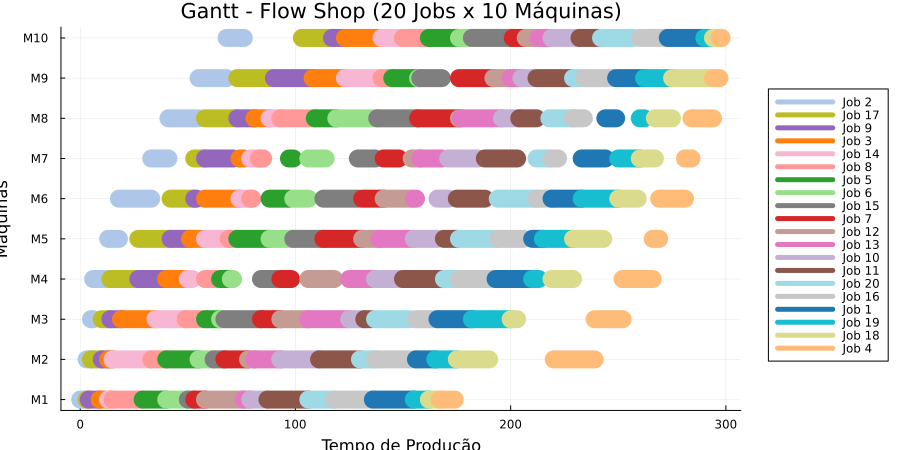

In [20]:
# ==========================================
# 4. TRATAMENTO DOS RESULTADOS E GANTT
# ==========================================

if termination_status(model) in [OPTIMAL, TIME_LIMIT]
    makespan_obtido = objective_value(model)
    println("\n==========================================")
    println("Status do Solver: ", termination_status(model))
    println("Makespan (Cmax) obtido: ", makespan_obtido)
    println("==========================================\n")
    
    # Descobrir a sequência ótima de tarefas encontrada
    sequencia_otima = Int[]
    for k in 1:num_jobs
        for j in 1:num_jobs
            if value(x[j, k]) > 0.5
                push!(sequencia_otima, j)
            end
        end
    end
    println("Sequência ótima dos Jobs: ", sequencia_otima)
    
    # Gerando o Gráfico de Gantt
    p = plot(title="Gantt - Flow Shop ($(num_jobs) Jobs x $(num_machines) Máquinas)", 
             xlabel="Tempo de Produção", ylabel="Máquinas", 
             yticks=(1:num_machines, ["M$m" for m in 1:num_machines]),
             legend=:outerright, size=(900, 450))
             
    # Paleta segura para evitar erros de renderização
    cor_paleta = palette(:tab20)
    
    # Reconstruindo os blocos de tempo para o gráfico
    for m in 1:num_machines
        for k in 1:num_jobs
            job_atual = sequencia_otima[k]
            tempo_termino = value(c[m, k])
            tempo_processamento = times[job_atual, m]
            tempo_inicio = tempo_termino - tempo_processamento
            
            # Desenha a barra apenas se houver tempo de processamento
            if tempo_processamento > 0
                plot!(p, [tempo_inicio, tempo_termino], [m, m], 
                      linewidth=18, label=(m == 1 ? "Job $job_atual" : ""), 
                      color=cor_paleta[mod1(job_atual, length(cor_paleta))])
            end
        end
    end
    
    display(p)
else
    println("Não foi encontrada uma solução viável dentro do limite estipulado.")
end

Instância problem_3m_10j
=============

In [21]:
using JuMP
using HiGHS
using Plots
using CSV
using DataFrames

In [22]:
# ==========================================
# 1. CARREGAMENTO E TRATAMENTO DOS DADOS
# ==========================================

# Altere o caminho se o arquivo não estiver na mesma pasta do script
nome_arquivo = "problem_3m_10j.csv"

println("Lendo o arquivo: ", nome_arquivo)
df = CSV.read(nome_arquivo, DataFrame)

Lendo o arquivo: problem_3m_10j.csv


Row,Column1,M1,M2,M3
,String3,Int64,Int64,Int64
1,J1,17,15,14
2,J2,18,16,6
3,J3,8,14,12
4,J4,1,15,10
5,J5,18,13,14
6,J6,15,9,1
7,J7,15,14,10
8,J8,3,5,4
9,J9,3,7,13


In [24]:
# Conversão dinâmica segura: ignora a primeira coluna caso ela seja um índice de texto (Ex: "Job 1")
# e transforma o restante em uma matriz pura de tempos de processamento.
if typeof(df[1, 1]) <: AbstractString
    matrix_dados = Matrix{Int64}(df[:, 2:end])
else
    matrix_dados = Matrix{Int64}(df)
end

10×3 Matrix{Int64}:
 17  15  14
 18  16   6
  8  14  12
  1  15  10
 18  13  14
 15   9   1
 15  14  10
  3   5   4
  3   7  13
  3  16  17

In [25]:
# No Flow Shop clássico da literatura:
# Linhas representam as Tarefas (Jobs) e Colunas representam as Máquinas (Machines)
num_jobs, num_machines = size(matrix_dados)

println("Dimensões detectadas com sucesso: ", num_jobs, " tarefas e ", num_machines, " máquinas.")

Dimensões detectadas com sucesso: 10 tarefas e 3 máquinas.


In [26]:
# Matriz de tempos p_jm (Tarefa j na Máquina m)
p = matrix_dados

10×3 Matrix{Int64}:
 17  15  14
 18  16   6
  8  14  12
  1  15  10
 18  13  14
 15   9   1
 15  14  10
  3   5   4
  3   7  13
  3  16  17

In [27]:
# ==========================================
# 2. CONSTRUÇÃO DO MODELO MATEMÁTICO (MILP)
# ==========================================

model = Model(HiGHS.Optimizer)

A JuMP Model
├ solver: HiGHS
├ objective_sense: FEASIBILITY_SENSE
├ num_variables: 0
├ num_constraints: 0
└ Names registered in the model: none

In [28]:
# Configurações obrigatórias da atividade
set_optimizer_attribute(model, "time_limit", 30.0)
set_optimizer_attribute(model, "mip_rel_gap", 0.0001)

In [29]:
# Variáveis de Decisão
# x[j, k] = 1 se a tarefa j ocupar a posição k na sequência de produção
@variable(model, x[1:num_jobs, 1:num_jobs], binary = true)

# c[m, k] = Tempo de término da tarefa que estiver ocupando a posição k na máquina m
@variable(model, c[1:num_machines, 1:num_jobs], lower_bound = 0.0)

# Cmax = Makespan (Tempo total de execução)
@variable(model, Cmax, lower_bound = 0.0)

# Função Objetivo
@objective(model, Min, Cmax)

Cmax

In [30]:
# Restrições de Atribuição (Garantir uma sequência perfeita por permutação)
for j in 1:num_jobs
    @constraint(model, sum(x[j, k] for k in 1:num_jobs) == 1) # Cada job está em exatamente uma posição
end

for k in 1:num_jobs
    @constraint(model, sum(x[j, k] for j in 1:num_jobs) == 1) # Cada posição tem exatamente um job
end

In [31]:
# Restrições de Sequenciamento nas Máquinas
# Máquina 1, Posição 1
@constraint(model, c[1, 1] == sum(p[j, 1] * x[j, 1] for j in 1:num_jobs))

# Máquina 1, Demais Posições (k > 1)
for k in 2:num_jobs
    @constraint(model, c[1, k] == c[1, k-1] + sum(p[j, 1] * x[j, k] for j in 1:num_jobs))
end

# Demais Máquinas (m > 1), Posição 1
for m in 2:num_machines
    @constraint(model, c[m, 1] == c[m-1, 1] + sum(p[j, m] * x[j, 1] for j in 1:num_jobs))
end

In [32]:
# Demais Máquinas (m > 1) e Demais Posições (k > 1)
for m in 2:num_machines
    for k in 2:num_jobs
        @constraint(model, c[m, k] >= c[m-1, k] + sum(p[j, m] * x[j, k] for j in 1:num_jobs))
        @constraint(model, c[m, k] >= c[m, k-1] + sum(p[j, m] * x[j, k] for j in 1:num_jobs))
    end
end

In [33]:
# O Makespan é limitado pelo término do último elemento na última máquina
@constraint(model, Cmax == c[num_machines, num_jobs])

-c[3,10] + Cmax == 0

In [35]:
# ==========================================
# 3. RESOLUÇÃO E EXTRAÇÃO DOS RESULTADOS
# ==========================================

optimize!(model)

status = termination_status(model)
println("\nStatus Final do Solver: ", status)

if status == OPTIMAL || status == TIME_LIMIT
    makespan_otimo = objective_value(model)
    println("Makespan (Cmax) obtido: ", makespan_otimo)
    
    # Recuperar a sequência ótima de produção
    sequencia = zeros(Int64, num_jobs)
    for k in 1:num_jobs
        for j in 1:num_jobs
            if value(x[j, k]) > 0.5
                sequencia[k] = j
            end
        end
    end
    println("Sequência Ótima Encontrada: ", sequencia)
    
    # Mapear tempos de início e término reais de cada Job para construir o Gantt
    start_times = zeros(num_jobs, num_machines)
    end_times = zeros(num_jobs, num_machines)
    
    for k in 1:num_jobs
        job_atual = sequencia[k]
        for m in 1:num_machines
            val_c = value(c[m, k])
            end_times[job_atual, m] = val_c
            start_times[job_atual, m] = val_c - p[job_atual, m]
        end
    end
end

MIP has 69 rows; 131 cols; 777 nonzeros; 100 integer variables (100 binary)
Coefficient ranges:
  Matrix  [1e+00, 2e+01]
  Cost    [1e+00, 1e+00]
  Bound   [1e+00, 1e+00]
  RHS     [1e+00, 1e+00]
Presolving model
68 rows, 130 cols, 775 nonzeros 0s
51 rows, 113 cols, 748 nonzeros 0s
51 rows, 113 cols, 644 nonzeros 0s
Presolve reductions: rows 51(-18); columns 113(-18); nonzeros 644(-133) 

Solving MIP model with:
   51 rows
   113 cols (100 binary, 0 integer, 2 implied int., 11 continuous, 0 domain fixed)
   644 nonzeros

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic;
     I => Shifting; J => Feasibility jump; L => Sub-MIP; P => Empty MIP; R => Randomized rounding;
     S => Solve LP; T => Evaluate node; U => Unbounded; X => User solution; Y => HiGHS solution;
     Z => ZI Round; l => Trivial lower; p => Trivial point; u => Trivial upper; z => Trivial zero

        Nodes      |    B&B Tree     |            Objective Bounds              |  Dynamic Cons

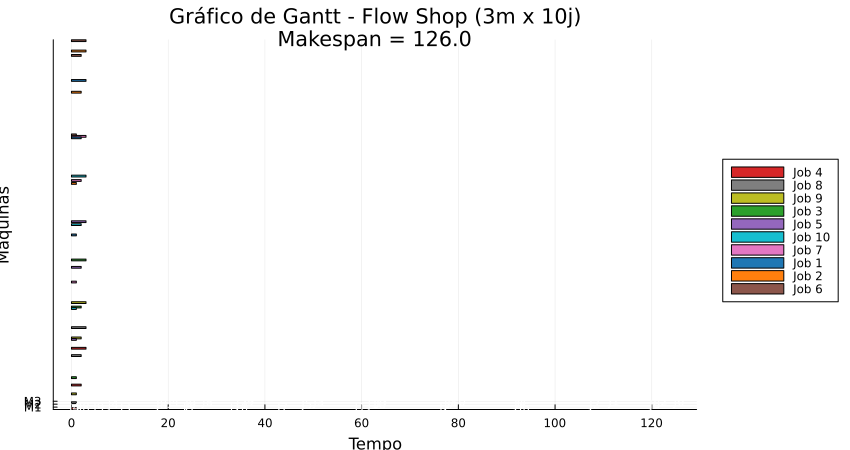

Gráfico de Gantt salvo com sucesso como 'gantt_problem_3m_10j.png'!


LoadError: ParseError:
[90m# Error @ [0;0m]8;;file://C:/Users/hercules.andre/Trabalho02_Otimização/In[36]#39:1\[90mIn[36]:39:1[0;0m]8;;\
    println("Gráfico de Gantt salvo com sucesso como 'gantt_problem_3m_10j.png'!")
[48;2;120;70;70melse[0;0m
[90m└──┘ ── [0;0m[91minvalid identifier[0;0m

In [36]:
# ==========================================
    # 4. GERAÇÃO DO GRÁFICO DE GANTT
    # ==========================================
    
    p_gantt = plot(
        title = "Gráfico de Gantt - Flow Shop (3m x 10j)\nMakespan = $makespan_otimo",
        xlabel = "Tempo",
        ylabel = "Máquinas",
        yticks = (1:num_machines, ["M$m" for m in 1:num_machines]),
        legend = :outerright,
        size = (850, 450)
    )
    
    # Paleta de cores estável para 10 Jobs
    cores = palette(:tab10)
    
    for k in 1:num_jobs
        j = sequencia[k]
        for m in 1:num_machines
            st = start_times[j, m]
            en = end_times[j, m]
            duracao = en - st
            
            # Desenha a barra horizontal da operação
            bar!(
                p_gantt,
                [st + duracao/2], [m], 
                bar_width=[0.6], orientation=:horizontal,
                fillcolor=cores[j], label = (m == 1 ? "Job $j" : "")
            )
            # Adiciona o rótulo do Job no centro do bloco
            annotate!(p_gantt, st + duracao/2, m, text("J$j", 8, :white, :center))
        end
    end
    
    display(p_gantt)
    savefig("gantt_problem_3m_10j.png")
    println("Gráfico de Gantt salvo com sucesso como 'gantt_problem_3m_10j.png'!")
else
    println("Não foi possível encontrar uma solução viável dentro do tempo estipulado.")
end

Instância problem_3m_20j
================

In [18]:
using CSV
using DataFrames
using JuMP
using HiGHS
using Plots

In [19]:
# =====================================================
# Leitura dos Dados
# =====================================================

println("Carregando instância...")

df = CSV.read("problem_3m_20j.csv", DataFrame)

if eltype(df[:,1]) <: AbstractString
    p = Matrix(df[:,2:end])
else
    p = Matrix(df)
end

n = size(p,1)
m = size(p,2)

println("Instância: $n tarefas × $m máquinas")

Carregando instância...
Instância: 20 tarefas × 3 máquinas


In [20]:
# =====================================================
# Modelo
# =====================================================

model = Model(HiGHS.Optimizer)
set_attribute(model,"time_limit",30.0)

@variable(model,x[1:n,1:n],Bin)

@variable(model,s[1:m,1:n] >= 0)

@variable(model,Cmax >= 0)

@objective(model,Min,Cmax)


Cmax

In [21]:
# Cada tarefa ocupa exatamente uma posição
@constraint(model,
    [j=1:n],
    sum(x[j,k] for k=1:n)==1)

20-element Vector{ConstraintRef{Model, MathOptInterface.ConstraintIndex{MathOptInterface.ScalarAffineFunction{Float64}, MathOptInterface.EqualTo{Float64}}, ScalarShape}}:
 x[1,1] + x[1,2] + x[1,3] + x[1,4] + x[1,5] + x[1,6] + x[1,7] + x[1,8] + x[1,9] + x[1,10] + x[1,11] + x[1,12] + x[1,13] + x[1,14] + x[1,15] + x[1,16] + x[1,17] + x[1,18] + x[1,19] + x[1,20] == 1
 x[2,1] + x[2,2] + x[2,3] + x[2,4] + x[2,5] + x[2,6] + x[2,7] + x[2,8] + x[2,9] + x[2,10] + x[2,11] + x[2,12] + x[2,13] + x[2,14] + x[2,15] + x[2,16] + x[2,17] + x[2,18] + x[2,19] + x[2,20] == 1
 x[3,1] + x[3,2] + x[3,3] + x[3,4] + x[3,5] + x[3,6] + x[3,7] + x[3,8] + x[3,9] + x[3,10] + x[3,11] + x[3,12] + x[3,13] + x[3,14] + x[3,15] + x[3,16] + x[3,17] + x[3,18] + x[3,19] + x[3,20] == 1
 x[4,1] + x[4,2] + x[4,3] + x[4,4] + x[4,5] + x[4,6] + x[4,7] + x[4,8] + x[4,9] + x[4,10] + x[4,11] + x[4,12] + x[4,13] + x[4,14] + x[4,15] + x[4,16] + x[4,17] + x[4,18] + x[4,19] + x[4,20] == 1
 x[5,1] + x[5,2] + x[5,3] + x[5,4] + x[5,5] + x[5

In [22]:
# Cada posição recebe exatamente uma tarefa
@constraint(model,
    [k=1:n],
    sum(x[j,k] for j=1:n)==1)

20-element Vector{ConstraintRef{Model, MathOptInterface.ConstraintIndex{MathOptInterface.ScalarAffineFunction{Float64}, MathOptInterface.EqualTo{Float64}}, ScalarShape}}:
 x[1,1] + x[2,1] + x[3,1] + x[4,1] + x[5,1] + x[6,1] + x[7,1] + x[8,1] + x[9,1] + x[10,1] + x[11,1] + x[12,1] + x[13,1] + x[14,1] + x[15,1] + x[16,1] + x[17,1] + x[18,1] + x[19,1] + x[20,1] == 1
 x[1,2] + x[2,2] + x[3,2] + x[4,2] + x[5,2] + x[6,2] + x[7,2] + x[8,2] + x[9,2] + x[10,2] + x[11,2] + x[12,2] + x[13,2] + x[14,2] + x[15,2] + x[16,2] + x[17,2] + x[18,2] + x[19,2] + x[20,2] == 1
 x[1,3] + x[2,3] + x[3,3] + x[4,3] + x[5,3] + x[6,3] + x[7,3] + x[8,3] + x[9,3] + x[10,3] + x[11,3] + x[12,3] + x[13,3] + x[14,3] + x[15,3] + x[16,3] + x[17,3] + x[18,3] + x[19,3] + x[20,3] == 1
 x[1,4] + x[2,4] + x[3,4] + x[4,4] + x[5,4] + x[6,4] + x[7,4] + x[8,4] + x[9,4] + x[10,4] + x[11,4] + x[12,4] + x[13,4] + x[14,4] + x[15,4] + x[16,4] + x[17,4] + x[18,4] + x[19,4] + x[20,4] == 1
 x[1,5] + x[2,5] + x[3,5] + x[4,5] + x[5,5] + x[6

In [23]:
# Precedência na mesma máquina
@constraint(model,
    [i=1:m,k=1:n-1],
    s[i,k+1] >=
        s[i,k] +
        sum(p[j,i]*x[j,k] for j=1:n)
)


3×19 Matrix{ConstraintRef{Model, MathOptInterface.ConstraintIndex{MathOptInterface.ScalarAffineFunction{Float64}, MathOptInterface.GreaterThan{Float64}}, ScalarShape}}:
 -2 x[1,1] - 14 x[2,1] - 13 x[3,1] - 7 x[4,1] - 17 x[5,1] - x[6,1] - 5 x[7,1] - 2 x[8,1] - 5 x[9,1] - 16 x[10,1] - 15 x[11,1] - 18 x[12,1] - 3 x[13,1] - 15 x[14,1] - 19 x[15,1] - 7 x[16,1] - 10 x[17,1] - 15 x[18,1] - 16 x[19,1] - 12 x[20,1] - s[1,1] + s[1,2] >= 0  …  -2 x[1,19] - 14 x[2,19] - 13 x[3,19] - 7 x[4,19] - 17 x[5,19] - x[6,19] - 5 x[7,19] - 2 x[8,19] - 5 x[9,19] - 16 x[10,19] - 15 x[11,19] - 18 x[12,19] - 3 x[13,19] - 15 x[14,19] - 19 x[15,19] - 7 x[16,19] - 10 x[17,19] - 15 x[18,19] - 16 x[19,19] - 12 x[20,19] - s[1,19] + s[1,20] >= 0
 -5 x[1,1] - 7 x[2,1] - 12 x[3,1] - 7 x[4,1] - 4 x[5,1] - 3 x[6,1] - 15 x[7,1] - 11 x[8,1] - 8 x[9,1] - 14 x[10,1] - 10 x[11,1] - 5 x[12,1] - 13 x[13,1] - 9 x[14,1] - 8 x[15,1] - 12 x[16,1] - 9 x[17,1] - 16 x[18,1] - 10 x[19,1] - 7 x[20,1] - s[2,1] + s[2,2] >= 0      -5 x[1,19]

In [24]:
# Precedência entre máquinas
@constraint(model,
    [i=1:m-1,k=1:n],
    s[i+1,k] >=
        s[i,k] +
        sum(p[j,i]*x[j,k] for j=1:n)
)


2×20 Matrix{ConstraintRef{Model, MathOptInterface.ConstraintIndex{MathOptInterface.ScalarAffineFunction{Float64}, MathOptInterface.GreaterThan{Float64}}, ScalarShape}}:
 -2 x[1,1] - 14 x[2,1] - 13 x[3,1] - 7 x[4,1] - 17 x[5,1] - x[6,1] - 5 x[7,1] - 2 x[8,1] - 5 x[9,1] - 16 x[10,1] - 15 x[11,1] - 18 x[12,1] - 3 x[13,1] - 15 x[14,1] - 19 x[15,1] - 7 x[16,1] - 10 x[17,1] - 15 x[18,1] - 16 x[19,1] - 12 x[20,1] - s[1,1] + s[2,1] >= 0  …  -2 x[1,20] - 14 x[2,20] - 13 x[3,20] - 7 x[4,20] - 17 x[5,20] - x[6,20] - 5 x[7,20] - 2 x[8,20] - 5 x[9,20] - 16 x[10,20] - 15 x[11,20] - 18 x[12,20] - 3 x[13,20] - 15 x[14,20] - 19 x[15,20] - 7 x[16,20] - 10 x[17,20] - 15 x[18,20] - 16 x[19,20] - 12 x[20,20] - s[1,20] + s[2,20] >= 0
 -5 x[1,1] - 7 x[2,1] - 12 x[3,1] - 7 x[4,1] - 4 x[5,1] - 3 x[6,1] - 15 x[7,1] - 11 x[8,1] - 8 x[9,1] - 14 x[10,1] - 10 x[11,1] - 5 x[12,1] - 13 x[13,1] - 9 x[14,1] - 8 x[15,1] - 12 x[16,1] - 9 x[17,1] - 16 x[18,1] - 10 x[19,1] - 7 x[20,1] - s[2,1] + s[3,1] >= 0      -5 x[1,20]

In [25]:
# Makespan
@constraint(model,
    Cmax >=
    s[m,n] +
    sum(p[j,m]*x[j,n] for j=1:n)
)

-x[1,20] - 18 x[2,20] - 3 x[3,20] - 4 x[4,20] - 2 x[5,20] - 12 x[6,20] - 3 x[7,20] - 15 x[8,20] - 14 x[9,20] - 10 x[10,20] - 14 x[11,20] - 13 x[12,20] - 13 x[13,20] - 16 x[14,20] - 4 x[15,20] - 7 x[16,20] - 13 x[17,20] - 16 x[18,20] - 3 x[19,20] - 19 x[20,20] - s[3,20] + Cmax >= 0

Resolvendo...
MIP has 138 rows; 461 cols; 2956 nonzeros; 400 integer variables (400 binary)
Coefficient ranges:
  Matrix  [1e+00, 2e+01]
  Cost    [1e+00, 1e+00]
  Bound   [1e+00, 1e+00]
  RHS     [1e+00, 1e+00]
Presolving model
137 rows, 459 cols, 2932 nonzeros 0s
121 rows, 443 cols, 2473 nonzeros 0s
Presolve reductions: rows 121(-17); columns 443(-18); nonzeros 2473(-483) 

Solving MIP model with:
   121 rows
   443 cols (400 binary, 0 integer, 0 implied int., 43 continuous, 0 domain fixed)
   2473 nonzeros

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic;
     I => Shifting; J => Feasibility jump; L => Sub-MIP; P => Empty MIP; R => Randomized rounding;
     S => Solve LP; T => Evaluate node; U => Unbounded; X => User solution; Y => HiGHS solution;
     Z => ZI Round; l => Trivial lower; p => Trivial point; u => Trivial upper; z => Trivial zero

        Nodes      |    B&B Tree     |            Objective Bounds              |  Dynamic Constraints |  

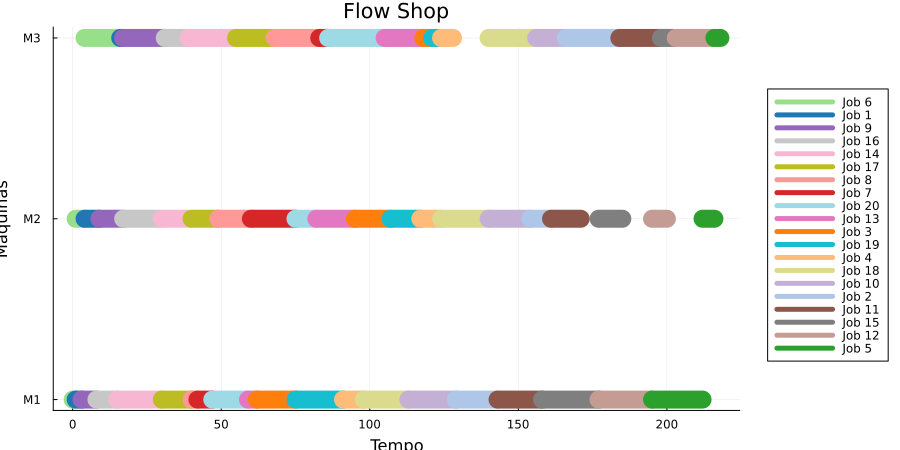

In [29]:
# =====================================================
# Resolver
# =====================================================

println("Resolvendo...")

optimize!(model)

println("Status: ",termination_status(model))

if has_values(model)

    println("Makespan = ",objective_value(model))

    sequencia = [
        argmax(value.(x[:,k]))
        for k in 1:n
    ]

    println("Sequência:")
    println(sequencia)

# =================================================
    # Gantt
    # =================================================

    cores = palette(:tab20)

    gantt = plot(
        xlabel="Tempo",
        ylabel="Máquinas",
        yticks=(1:m,["M$i" for i=1:m]),
        legend=:outerright,
        size=(900,450),
        title="Flow Shop"
    )

    for maq in 1:m
        for pos in 1:n

            job = sequencia[pos]

            inicio = value(s[maq,pos])

            fim = inicio + p[job,maq]

            plot!(
                gantt,
                [inicio,fim],
                [maq,maq],
                linewidth=18,
                color=cores[job],
                label=(maq==1 ? "Job $job" : "")
            )

        end
    end

    savefig(gantt,"gantt_problem_3m_20j.png")
    display(gantt)

else

    println("Nenhuma solução viável encontrada.")

end

    

Instância problem_5m_10j
====================

In [30]:
using JuMP, HiGHS, CSV, DataFrames, Plots

In [31]:
# --- 1. CARREGAMENTO DOS DADOS ---
# Certifique-se de que o arquivo está na mesma pasta do script
file_path = "problem_5m_10j.csv"
df = CSV.read(file_path, DataFrame)

Row,Column1,M1,M2,M3,M4,M5
,String3,Int64,Int64,Int64,Int64,Int64
1,J1,1,4,7,11,14
2,J2,15,13,6,6,16
3,J3,2,8,16,13,8
4,J4,10,1,13,5,3
5,J5,17,6,13,16,14
6,J6,2,15,6,9,19
7,J7,16,8,13,3,3
8,J8,16,5,10,11,16
9,J9,18,3,17,12,4


In [32]:
# Remove a primeira coluna se for textual (ex: "Job 1") para evitar erro de conversão
# Se o seu CSV tiver apenas números, pode comentar a linha abaixo
times_matrix = Matrix(df[:, 2:end]) 

num_jobs, num_machines = size(times_matrix)

(10, 5)

In [33]:
# --- 2. MODELAGEM MATEMÁTICA (Permutation Flow Shop) ---
model = Model(HiGHS.Optimizer)

# Configurações do Solver
set_attribute(model, "time_limit", 30.0) # Limite de 30 segundos conforme diretrizes
set_attribute(model, "mip_rel_gap", 0.0001) # Tolerância de gap

In [34]:
# Variáveis de Decisão
# x[j, k] = 1 se o job j está na posição k da sequência
@variable(model, x[1:num_jobs, 1:num_jobs], binary = true)
# C[k, m] = Tempo de término do job na posição k na máquina m
@variable(model, C[1:num_jobs, 1:num_machines] >= 0)


10×5 Matrix{VariableRef}:
 C[1,1]   C[1,2]   C[1,3]   C[1,4]   C[1,5]
 C[2,1]   C[2,2]   C[2,3]   C[2,4]   C[2,5]
 C[3,1]   C[3,2]   C[3,3]   C[3,4]   C[3,5]
 C[4,1]   C[4,2]   C[4,3]   C[4,4]   C[4,5]
 C[5,1]   C[5,2]   C[5,3]   C[5,4]   C[5,5]
 C[6,1]   C[6,2]   C[6,3]   C[6,4]   C[6,5]
 C[7,1]   C[7,2]   C[7,3]   C[7,4]   C[7,5]
 C[8,1]   C[8,2]   C[8,3]   C[8,4]   C[8,5]
 C[9,1]   C[9,2]   C[9,3]   C[9,4]   C[9,5]
 C[10,1]  C[10,2]  C[10,3]  C[10,4]  C[10,5]

In [35]:
# Restrições de Posição
for j in 1:num_jobs
    @constraint(model, sum(x[j, k] for k in 1:num_jobs) == 1) # Cada job em uma posição
end
for k in 1:num_jobs
    @constraint(model, sum(x[j, k] for j in 1:num_jobs) == 1) # Cada posição com um job
end

In [36]:
# Restrições de Sequenciamento e Precedência
for k in 1:num_jobs
    for m in 1:num_machines
        # Tempo de processamento do job na posição k na máquina m
        p_km = sum(times_matrix[j, m] * x[j, k] for j in 1:num_jobs)
        
        if k == 1 && m == 1
            @constraint(model, C[k, m] == p_km)
        elseif k == 1
            @constraint(model, C[k, m] == C[k, m-1] + p_km)
        elseif m == 1
            @constraint(model, C[k, m] == C[k-1, m] + p_km)
        else
            @constraint(model, C[k, m] >= C[k, m-1] + p_km)
            @constraint(model, C[k, m] >= C[k-1, m] + p_km)
        end
    end
end

In [37]:
# Função Objetivo: Minimizar o Makespan (término do último job na última máquina)
@objective(model, Min, C[num_jobs, num_machines])

C[10,5]

In [38]:
# --- 3. RESOLUÇÃO ---
println("Iniciando otimização da instância problem_5m_10j...")
optimize!(model)

Iniciando otimização da instância problem_5m_10j...
Running HiGHS 1.14.0 (git hash: 7df0786de3): Copyright (c) 2026 under Apache 2.0 license terms
Using BLAS: blastrampoline-5 
MIP has 106 rows; 150 cols; 1231 nonzeros; 100 integer variables (100 binary)
Coefficient ranges:
  Matrix  [1e+00, 2e+01]
  Cost    [1e+00, 1e+00]
  Bound   [1e+00, 1e+00]
  RHS     [1e+00, 1e+00]
Presolving model
106 rows, 150 cols, 1231 nonzeros 0s
87 rows, 131 cols, 992 nonzeros 0s
Presolve reductions: rows 87(-19); columns 131(-19); nonzeros 992(-239) 

Solving MIP model with:
   87 rows
   131 cols (100 binary, 0 integer, 3 implied int., 28 continuous, 0 domain fixed)
   992 nonzeros

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic;
     I => Shifting; J => Feasibility jump; L => Sub-MIP; P => Empty MIP; R => Randomized rounding;
     S => Solve LP; T => Evaluate node; U => Unbounded; X => User solution; Y => HiGHS solution;
     Z => ZI Round; l => Trivial lower; p => Tri


Makespan (Cmax) obtido: 129.0000000000001


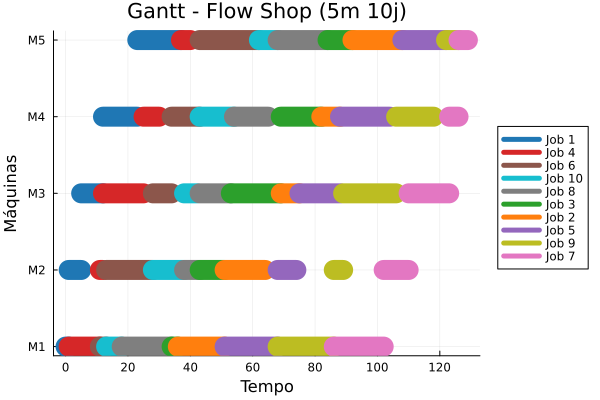

Gráfico salvo como 'gantt_problem_5m_10j.png'.


In [39]:
# --- 4. RESULTADOS E GRÁFICO DE GANTT ---
if termination_status(model) == OPTIMAL || termination_status(model) == TIME_LIMIT
    c_max = objective_value(model)
    println("\nMakespan (Cmax) obtido: ", c_max)
    
    # Gerando o Gráfico de Gantt
    p_gantt = plot(title="Gantt - Flow Shop (5m 10j)", xlabel="Tempo", ylabel="Máquinas",
                   yticks=(1:num_machines, ["M$m" for m in 1:num_machines]), legend=:outerright)
    
    # Cores distintas para os 10 jobs
    cores = palette(:tab10, num_jobs) 
    
    for k in 1:num_jobs
        # Identifica qual job real está nesta posição k
        job_idx = findfirst(v -> v > 0.5, [value(x[j, k]) for j in 1:num_jobs])
        for m in 1:num_machines
            duracao = times_matrix[job_idx, m]
            termino = value(C[k, m])
            inicio = termino - duracao
            
            # Desenha a barra do Job
            plot!(p_gantt, [inicio, termino], [m, m], linewidth=20, color=cores[job_idx], label=(m==1 ? "Job $job_idx" : ""))
        end
    end
    display(p_gantt)
    savefig("gantt_problem_5m_10j.png")
    println("Gráfico salvo como 'gantt_problem_5m_10j.png'.")
else
    println("O solver não encontrou uma solução viável.")
end

In [40]:
# --- EXTRAÇÃO DA SEQUÊNCIA ÓTIMA ---
if termination_status(model) == OPTIMAL || termination_status(model) == TIME_LIMIT
    # Criamos um vetor para armazenar a ordem dos jobs
    sequencia_jobs = Int[]
    
    for k in 1:num_jobs          # Para cada posição na fila (k)
        for j in 1:num_jobs      # Procuramos qual job (j) foi alocado ali
            if value(x[j, k]) > 0.5
                push!(sequencia_jobs, j)
            end
        end
    end
    
    # Exibição no terminal
    println("\n" * "="^30)
    println("      RESULTADOS FINAIS")
    println("="^30)
    println("Makespan (Cmax): ", objective_value(model))
    println("Sequência Ótima: ", join(["Job $j" for j in sequencia_jobs], " -> "))
    println("="^30)
else
    println("Não foi encontrada uma solução viável no tempo estipulado.")
end


      RESULTADOS FINAIS
Makespan (Cmax): 129.0000000000001
Sequência Ótima: Job 1 -> Job 4 -> Job 6 -> Job 10 -> Job 8 -> Job 3 -> Job 2 -> Job 5 -> Job 9 -> Job 7


Instância problem_5m_30j
==========

In [7]:
using CSV
using DataFrames
using JuMP
using HiGHS
using Plots

In [8]:
# ==========================================================
# LEITURA DA INSTÂNCIA
# ==========================================================

println("Carregando instância...")

arquivo = "problem_5m_30j.csv"

df = CSV.read(arquivo, DataFrame)

Carregando instância...


Row,Column1,M1,M2,M3,M4,M5
,String3,Int64,Int64,Int64,Int64,Int64
1,J1,19,18,2,3,9
2,J2,19,3,19,11,4
3,J3,3,11,18,2,3
4,J4,12,19,16,7,6
5,J5,9,16,16,2,16
6,J6,12,13,10,6,1
7,J7,9,2,4,5,13
8,J8,1,3,9,15,19
9,J9,4,6,15,19,17


In [9]:
# Verifica se existe uma coluna de identificação das tarefas
if eltype(df[:,1]) <: AbstractString
    p = Matrix(df[:,2:end])
else
    p = Matrix(df)
end

num_jobs = size(p,1)
num_machines = size(p,2)

println("Instância carregada com sucesso!")
println("Número de tarefas : $num_jobs")
println("Número de máquinas: $num_machines")

Instância carregada com sucesso!
Número de tarefas : 30
Número de máquinas: 5


In [10]:
# ==========================================================
# MODELO MATEMÁTICO
# ==========================================================

model = Model(HiGHS.Optimizer)

# Tempo máximo de execução (segundos)
set_attribute(model, "time_limit", 30.0)

# Variáveis de decisão

@variable(model, x[1:num_jobs,1:num_jobs], Bin)

@variable(model, s[1:num_machines,1:num_jobs] >= 0)

@variable(model, Cmax >= 0)

# Função objetivo

@objective(model, Min, Cmax)

Cmax

In [11]:
# ==========================================================
# RESTRIÇÕES
# ==========================================================

# Cada tarefa ocupa exatamente uma posição

@constraint(model,
    [j=1:num_jobs],
    sum(x[j,k] for k in 1:num_jobs) == 1
)

# Cada posição recebe exatamente uma tarefa

@constraint(model,
    [k=1:num_jobs],
    sum(x[j,k] for j in 1:num_jobs) == 1
)

30-element Vector{ConstraintRef{Model, MathOptInterface.ConstraintIndex{MathOptInterface.ScalarAffineFunction{Float64}, MathOptInterface.EqualTo{Float64}}, ScalarShape}}:
 x[1,1] + x[2,1] + x[3,1] + x[4,1] + x[5,1] + x[6,1] + x[7,1] + x[8,1] + x[9,1] + x[10,1] + x[11,1] + x[12,1] + x[13,1] + x[14,1] + x[15,1] + x[16,1] + x[17,1] + x[18,1] + x[19,1] + x[20,1] + x[21,1] + x[22,1] + x[23,1] + x[24,1] + x[25,1] + x[26,1] + x[27,1] + x[28,1] + x[29,1] + x[30,1] == 1
 x[1,2] + x[2,2] + x[3,2] + x[4,2] + x[5,2] + x[6,2] + x[7,2] + x[8,2] + x[9,2] + x[10,2] + x[11,2] + x[12,2] + x[13,2] + x[14,2] + x[15,2] + x[16,2] + x[17,2] + x[18,2] + x[19,2] + x[20,2] + x[21,2] + x[22,2] + x[23,2] + x[24,2] + x[25,2] + x[26,2] + x[27,2] + x[28,2] + x[29,2] + x[30,2] == 1
 x[1,3] + x[2,3] + x[3,3] + x[4,3] + x[5,3] + x[6,3] + x[7,3] + x[8,3] + x[9,3] + x[10,3] + x[11,3] + x[12,3] + x[13,3] + x[14,3] + x[15,3] + x[16,3] + x[17,3] + x[18,3] + x[19,3] + x[20,3] + x[21,3] + x[22,3] + x[23,3] + x[24,3] + x[25,3]

In [12]:
# Precedência na mesma máquina

@constraint(model,
    [m=1:num_machines, k=1:num_jobs-1],
    s[m,k+1] >=
        s[m,k] +
        sum(p[j,m]*x[j,k] for j in 1:num_jobs)
)

5×29 Matrix{ConstraintRef{Model, MathOptInterface.ConstraintIndex{MathOptInterface.ScalarAffineFunction{Float64}, MathOptInterface.GreaterThan{Float64}}, ScalarShape}}:
 -19 x[1,1] - 19 x[2,1] - 3 x[3,1] - 12 x[4,1] - 9 x[5,1] - 12 x[6,1] - 9 x[7,1] - x[8,1] - 4 x[9,1] - 10 x[10,1] - 5 x[11,1] - x[12,1] - 8 x[13,1] - 18 x[14,1] - 9 x[15,1] - 16 x[16,1] - 17 x[17,1] - 3 x[18,1] - 15 x[19,1] - 4 x[20,1] - x[21,1] - 13 x[22,1] - 5 x[23,1] - 16 x[24,1] - 9 x[25,1] - 19 x[26,1] - 2 x[27,1] - 16 x[28,1] - 14 x[29,1] - 4 x[30,1] - s[1,1] + s[1,2] >= 0          …  -19 x[1,29] - 19 x[2,29] - 3 x[3,29] - 12 x[4,29] - 9 x[5,29] - 12 x[6,29] - 9 x[7,29] - x[8,29] - 4 x[9,29] - 10 x[10,29] - 5 x[11,29] - x[12,29] - 8 x[13,29] - 18 x[14,29] - 9 x[15,29] - 16 x[16,29] - 17 x[17,29] - 3 x[18,29] - 15 x[19,29] - 4 x[20,29] - x[21,29] - 13 x[22,29] - 5 x[23,29] - 16 x[24,29] - 9 x[25,29] - 19 x[26,29] - 2 x[27,29] - 16 x[28,29] - 14 x[29,29] - 4 x[30,29] - s[1,29] + s[1,30] >= 0
 -18 x[1,1] - 3 x[2,1] -

In [13]:
# Precedência entre máquinas

@constraint(model,
    [m=1:num_machines-1, k=1:num_jobs],
    s[m+1,k] >=
        s[m,k] +
        sum(p[j,m]*x[j,k] for j in 1:num_jobs)
)


4×30 Matrix{ConstraintRef{Model, MathOptInterface.ConstraintIndex{MathOptInterface.ScalarAffineFunction{Float64}, MathOptInterface.GreaterThan{Float64}}, ScalarShape}}:
 -19 x[1,1] - 19 x[2,1] - 3 x[3,1] - 12 x[4,1] - 9 x[5,1] - 12 x[6,1] - 9 x[7,1] - x[8,1] - 4 x[9,1] - 10 x[10,1] - 5 x[11,1] - x[12,1] - 8 x[13,1] - 18 x[14,1] - 9 x[15,1] - 16 x[16,1] - 17 x[17,1] - 3 x[18,1] - 15 x[19,1] - 4 x[20,1] - x[21,1] - 13 x[22,1] - 5 x[23,1] - 16 x[24,1] - 9 x[25,1] - 19 x[26,1] - 2 x[27,1] - 16 x[28,1] - 14 x[29,1] - 4 x[30,1] - s[1,1] + s[2,1] >= 0          …  -19 x[1,30] - 19 x[2,30] - 3 x[3,30] - 12 x[4,30] - 9 x[5,30] - 12 x[6,30] - 9 x[7,30] - x[8,30] - 4 x[9,30] - 10 x[10,30] - 5 x[11,30] - x[12,30] - 8 x[13,30] - 18 x[14,30] - 9 x[15,30] - 16 x[16,30] - 17 x[17,30] - 3 x[18,30] - 15 x[19,30] - 4 x[20,30] - x[21,30] - 13 x[22,30] - 5 x[23,30] - 16 x[24,30] - 9 x[25,30] - 19 x[26,30] - 2 x[27,30] - 16 x[28,30] - 14 x[29,30] - 4 x[30,30] - s[1,30] + s[2,30] >= 0
 -18 x[1,1] - 3 x[2,1] -

In [14]:
# Makespan

@constraint(model,
    Cmax >=
    s[num_machines,num_jobs] +
    sum(p[j,num_machines]*x[j,num_jobs] for j in 1:num_jobs)
)


-9 x[1,30] - 4 x[2,30] - 3 x[3,30] - 6 x[4,30] - 16 x[5,30] - x[6,30] - 13 x[7,30] - 19 x[8,30] - 17 x[9,30] - 14 x[10,30] - 13 x[11,30] - 3 x[12,30] - x[13,30] - 13 x[14,30] - 5 x[15,30] - 2 x[16,30] - 18 x[17,30] - 8 x[18,30] - 9 x[19,30] - 14 x[20,30] - 8 x[21,30] - 2 x[22,30] - 10 x[23,30] - 9 x[24,30] - x[25,30] - 9 x[26,30] - 17 x[27,30] - 14 x[28,30] - 5 x[29,30] - 2 x[30,30] - s[5,30] + Cmax >= 0

In [15]:
# ==========================================================
# OTIMIZAÇÃO
# ==========================================================

println("\nIniciando otimização...")

optimize!(model)

status = termination_status(model)

println("\nStatus do Solver: ", status)



Iniciando otimização...
Running HiGHS 1.14.0 (git hash: 7df0786de3): Copyright (c) 2026 under Apache 2.0 license terms
Using BLAS: blastrampoline-5 
MIP has 326 rows; 1051 cols; 10312 nonzeros; 900 integer variables (900 binary)
Coefficient ranges:
  Matrix  [1e+00, 2e+01]
  Cost    [1e+00, 1e+00]
  Bound   [1e+00, 1e+00]
  RHS     [1e+00, 1e+00]
Presolving model
325 rows, 1049 cols, 10278 nonzeros 0s
319 rows, 1043 cols, 9160 nonzeros 0s
Presolve reductions: rows 319(-7); columns 1043(-8); nonzeros 9160(-1152) 

Solving MIP model with:
   319 rows
   1043 cols (900 binary, 0 integer, 0 implied int., 143 continuous, 0 domain fixed)
   9160 nonzeros

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic;
     I => Shifting; J => Feasibility jump; L => Sub-MIP; P => Empty MIP; R => Randomized rounding;
     S => Solve LP; T => Evaluate node; U => Unbounded; X => User solution; Y => HiGHS solution;
     Z => ZI Round; l => Trivial lower; p => Trivial point; u 

----------------------------------------
Makespan = 326.9999999999998
----------------------------------------
Sequência encontrada:
[8, 18, 3, 30, 7, 13, 27, 28, 11, 10, 20, 23, 6, 9, 12, 19, 5, 24, 17, 21, 1, 15, 2, 4, 14, 26, 16, 29, 25, 22]

Gráfico salvo como:
gantt_problem_5m_30j.png


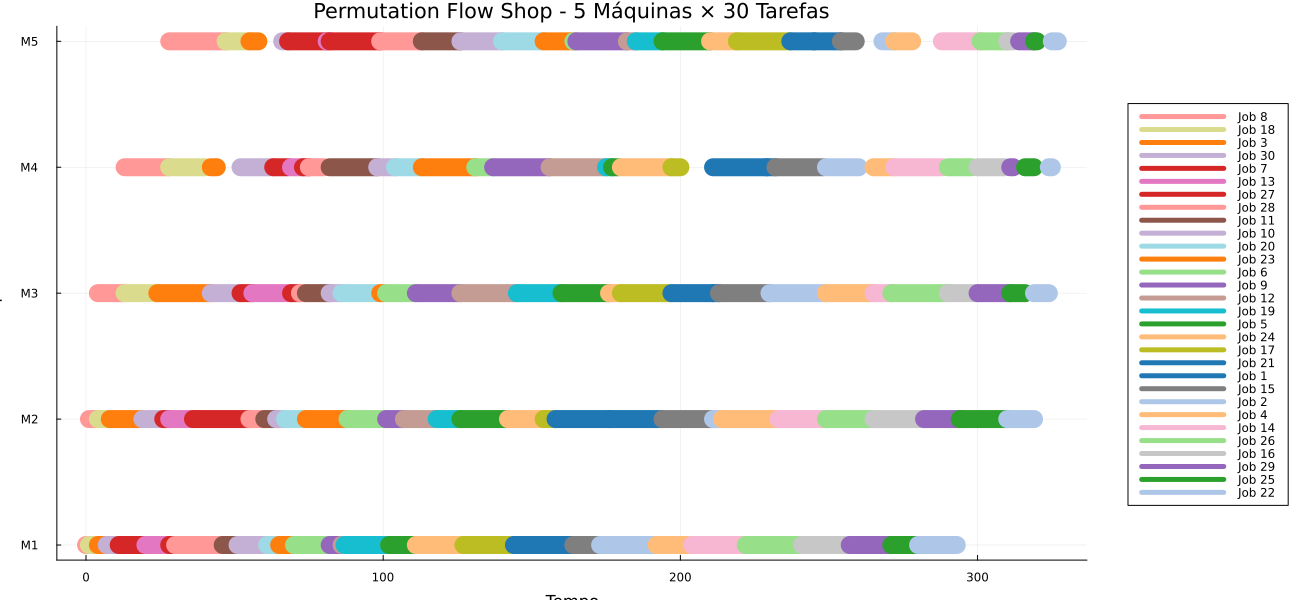

In [16]:
# ==========================================================
# RESULTADOS
# ==========================================================

if has_values(model)

    println("----------------------------------------")
    println("Makespan = ", objective_value(model))
    println("----------------------------------------")

    sequencia = Int[]

    for k in 1:num_jobs
        for j in 1:num_jobs
            if value(x[j,k]) > 0.5
                push!(sequencia,j)
            end
        end
    end

    println("Sequência encontrada:")
    println(sequencia)

    # ======================================================
    # GRÁFICO DE GANTT
    # ======================================================

    cores = palette(:tab20)

    gantt = plot(
        title = "Permutation Flow Shop - 5 Máquinas × 30 Tarefas",
        xlabel = "Tempo",
        ylabel = "Máquinas",
        yticks = (1:num_machines, ["M$i" for i in 1:num_machines]),
        legend = :outerright,
        size = (1300,600)
    )

    for m in 1:num_machines

        for k in 1:num_jobs

            job = sequencia[k]

            inicio = value(s[m,k])

            termino = inicio + p[job,m]

            plot!(
                gantt,
                [inicio, termino],
                [m, m],
                linewidth = 18,
                color = cores[mod1(job,20)],
                label = (m == 1 ? "Job $job" : "")
            )

        end

    end

    savefig(gantt,"gantt_problem_5m_30j.png")

    println("\nGráfico salvo como:")
    println("gantt_problem_5m_30j.png")

    display(gantt)

else

    println("Nenhuma solução viável foi encontrada.")

end

Intancia problem_5m_20j
===

In [17]:
using CSV
using DataFrames
using JuMP
using HiGHS
using Plots

In [18]:
# ==========================================================
# 1. LEITURA DA INSTÂNCIA
# ==========================================================

println("Carregando instância...")

arquivo = "problem_5m_20j.csv"

df = CSV.read(arquivo, DataFrame)

Carregando instância...


Row,Column1,M1,M2,M3,M4,M5
,String3,Int64,Int64,Int64,Int64,Int64
1,J1,3,8,10,16,12
2,J2,14,12,4,4,7
3,J3,14,16,19,18,15
4,J4,8,13,1,10,18
5,J5,18,9,12,14,13
6,J6,8,7,10,6,6
7,J7,4,19,2,2,10
8,J8,2,14,8,18,9
9,J9,9,18,8,10,16


In [19]:
# Remove a primeira coluna caso ela contenha o identificador das tarefas
if eltype(df[:,1]) <: AbstractString
    p = Matrix(df[:,2:end])
else
    p = Matrix(df)
end

num_jobs = size(p,1)
num_machines = size(p,2)

println("Instância carregada com sucesso!")
println("Número de tarefas : $num_jobs")
println("Número de máquinas: $num_machines")

Instância carregada com sucesso!
Número de tarefas : 20
Número de máquinas: 5


In [20]:
# ==========================================================
# 2. MODELO MATEMÁTICO
# ==========================================================

model = Model(HiGHS.Optimizer)

# Limite máximo de tempo (30 segundos)
set_attribute(model,"time_limit",30.0)

# Variáveis de decisão

@variable(model, x[1:num_jobs,1:num_jobs], Bin)

@variable(model, s[1:num_machines,1:num_jobs] >= 0)

@variable(model, Cmax >= 0)

# Função objetivo

@objective(model, Min, Cmax)

Cmax

In [21]:
# ==========================================================
# 3. RESTRIÇÕES
# ==========================================================

# Cada tarefa ocupa exatamente uma posição

@constraint(model,
    [j=1:num_jobs],
    sum(x[j,k] for k in 1:num_jobs) == 1
)


20-element Vector{ConstraintRef{Model, MathOptInterface.ConstraintIndex{MathOptInterface.ScalarAffineFunction{Float64}, MathOptInterface.EqualTo{Float64}}, ScalarShape}}:
 x[1,1] + x[1,2] + x[1,3] + x[1,4] + x[1,5] + x[1,6] + x[1,7] + x[1,8] + x[1,9] + x[1,10] + x[1,11] + x[1,12] + x[1,13] + x[1,14] + x[1,15] + x[1,16] + x[1,17] + x[1,18] + x[1,19] + x[1,20] == 1
 x[2,1] + x[2,2] + x[2,3] + x[2,4] + x[2,5] + x[2,6] + x[2,7] + x[2,8] + x[2,9] + x[2,10] + x[2,11] + x[2,12] + x[2,13] + x[2,14] + x[2,15] + x[2,16] + x[2,17] + x[2,18] + x[2,19] + x[2,20] == 1
 x[3,1] + x[3,2] + x[3,3] + x[3,4] + x[3,5] + x[3,6] + x[3,7] + x[3,8] + x[3,9] + x[3,10] + x[3,11] + x[3,12] + x[3,13] + x[3,14] + x[3,15] + x[3,16] + x[3,17] + x[3,18] + x[3,19] + x[3,20] == 1
 x[4,1] + x[4,2] + x[4,3] + x[4,4] + x[4,5] + x[4,6] + x[4,7] + x[4,8] + x[4,9] + x[4,10] + x[4,11] + x[4,12] + x[4,13] + x[4,14] + x[4,15] + x[4,16] + x[4,17] + x[4,18] + x[4,19] + x[4,20] == 1
 x[5,1] + x[5,2] + x[5,3] + x[5,4] + x[5,5] + x[5

In [22]:
# Cada posição recebe exatamente uma tarefa

@constraint(model,
    [k=1:num_jobs],
    sum(x[j,k] for j in 1:num_jobs) == 1
)

20-element Vector{ConstraintRef{Model, MathOptInterface.ConstraintIndex{MathOptInterface.ScalarAffineFunction{Float64}, MathOptInterface.EqualTo{Float64}}, ScalarShape}}:
 x[1,1] + x[2,1] + x[3,1] + x[4,1] + x[5,1] + x[6,1] + x[7,1] + x[8,1] + x[9,1] + x[10,1] + x[11,1] + x[12,1] + x[13,1] + x[14,1] + x[15,1] + x[16,1] + x[17,1] + x[18,1] + x[19,1] + x[20,1] == 1
 x[1,2] + x[2,2] + x[3,2] + x[4,2] + x[5,2] + x[6,2] + x[7,2] + x[8,2] + x[9,2] + x[10,2] + x[11,2] + x[12,2] + x[13,2] + x[14,2] + x[15,2] + x[16,2] + x[17,2] + x[18,2] + x[19,2] + x[20,2] == 1
 x[1,3] + x[2,3] + x[3,3] + x[4,3] + x[5,3] + x[6,3] + x[7,3] + x[8,3] + x[9,3] + x[10,3] + x[11,3] + x[12,3] + x[13,3] + x[14,3] + x[15,3] + x[16,3] + x[17,3] + x[18,3] + x[19,3] + x[20,3] == 1
 x[1,4] + x[2,4] + x[3,4] + x[4,4] + x[5,4] + x[6,4] + x[7,4] + x[8,4] + x[9,4] + x[10,4] + x[11,4] + x[12,4] + x[13,4] + x[14,4] + x[15,4] + x[16,4] + x[17,4] + x[18,4] + x[19,4] + x[20,4] == 1
 x[1,5] + x[2,5] + x[3,5] + x[4,5] + x[5,5] + x[6

In [23]:
# Restrição de precedência na mesma máquina

@constraint(model,
    [m=1:num_machines, k=1:num_jobs-1],
    s[m,k+1] >=
        s[m,k] +
        sum(p[j,m]*x[j,k] for j in 1:num_jobs)
)

5×19 Matrix{ConstraintRef{Model, MathOptInterface.ConstraintIndex{MathOptInterface.ScalarAffineFunction{Float64}, MathOptInterface.GreaterThan{Float64}}, ScalarShape}}:
 -3 x[1,1] - 14 x[2,1] - 14 x[3,1] - 8 x[4,1] - 18 x[5,1] - 8 x[6,1] - 4 x[7,1] - 2 x[8,1] - 9 x[9,1] - 2 x[10,1] - x[11,1] - 9 x[12,1] - 7 x[13,1] - 10 x[14,1] - 8 x[15,1] - 3 x[16,1] - 18 x[17,1] - 17 x[18,1] - 6 x[19,1] - 15 x[20,1] - s[1,1] + s[1,2] >= 0           …  -3 x[1,19] - 14 x[2,19] - 14 x[3,19] - 8 x[4,19] - 18 x[5,19] - 8 x[6,19] - 4 x[7,19] - 2 x[8,19] - 9 x[9,19] - 2 x[10,19] - x[11,19] - 9 x[12,19] - 7 x[13,19] - 10 x[14,19] - 8 x[15,19] - 3 x[16,19] - 18 x[17,19] - 17 x[18,19] - 6 x[19,19] - 15 x[20,19] - s[1,19] + s[1,20] >= 0
 -8 x[1,1] - 12 x[2,1] - 16 x[3,1] - 13 x[4,1] - 9 x[5,1] - 7 x[6,1] - 19 x[7,1] - 14 x[8,1] - 18 x[9,1] - 9 x[10,1] - 19 x[11,1] - 9 x[12,1] - 5 x[13,1] - 5 x[14,1] - 15 x[15,1] - 13 x[16,1] - 13 x[17,1] - 5 x[18,1] - 12 x[19,1] - 8 x[20,1] - s[2,1] + s[2,2] >= 0        -8 x[1,

In [24]:
# Restrição de precedência entre máquinas

@constraint(model,
    [m=1:num_machines-1, k=1:num_jobs],
    s[m+1,k] >=
        s[m,k] +
        sum(p[j,m]*x[j,k] for j in 1:num_jobs)
)

4×20 Matrix{ConstraintRef{Model, MathOptInterface.ConstraintIndex{MathOptInterface.ScalarAffineFunction{Float64}, MathOptInterface.GreaterThan{Float64}}, ScalarShape}}:
 -3 x[1,1] - 14 x[2,1] - 14 x[3,1] - 8 x[4,1] - 18 x[5,1] - 8 x[6,1] - 4 x[7,1] - 2 x[8,1] - 9 x[9,1] - 2 x[10,1] - x[11,1] - 9 x[12,1] - 7 x[13,1] - 10 x[14,1] - 8 x[15,1] - 3 x[16,1] - 18 x[17,1] - 17 x[18,1] - 6 x[19,1] - 15 x[20,1] - s[1,1] + s[2,1] >= 0        …  -3 x[1,20] - 14 x[2,20] - 14 x[3,20] - 8 x[4,20] - 18 x[5,20] - 8 x[6,20] - 4 x[7,20] - 2 x[8,20] - 9 x[9,20] - 2 x[10,20] - x[11,20] - 9 x[12,20] - 7 x[13,20] - 10 x[14,20] - 8 x[15,20] - 3 x[16,20] - 18 x[17,20] - 17 x[18,20] - 6 x[19,20] - 15 x[20,20] - s[1,20] + s[2,20] >= 0
 -8 x[1,1] - 12 x[2,1] - 16 x[3,1] - 13 x[4,1] - 9 x[5,1] - 7 x[6,1] - 19 x[7,1] - 14 x[8,1] - 18 x[9,1] - 9 x[10,1] - 19 x[11,1] - 9 x[12,1] - 5 x[13,1] - 5 x[14,1] - 15 x[15,1] - 13 x[16,1] - 13 x[17,1] - 5 x[18,1] - 12 x[19,1] - 8 x[20,1] - s[2,1] + s[3,1] >= 0     -8 x[1,20] - 

In [25]:
# Restrição do Makespan

@constraint(model,
    Cmax >=
        s[num_machines,num_jobs] +
        sum(p[j,num_machines]*x[j,num_jobs] for j in 1:num_jobs)
)


-12 x[1,20] - 7 x[2,20] - 15 x[3,20] - 18 x[4,20] - 13 x[5,20] - 6 x[6,20] - 10 x[7,20] - 9 x[8,20] - 16 x[9,20] - 17 x[10,20] - 13 x[11,20] - 12 x[12,20] - 11 x[13,20] - 13 x[14,20] - 16 x[15,20] - 14 x[16,20] - 18 x[17,20] - 9 x[18,20] - 5 x[19,20] - 4 x[20,20] - s[5,20] + Cmax >= 0

In [26]:
# ==========================================================
# 4. OTIMIZAÇÃO
# ==========================================================

println("\nIniciando otimização...")

optimize!(model)

status = termination_status(model)

println("\nStatus do Solver: ", status)



Iniciando otimização...
Running HiGHS 1.14.0 (git hash: 7df0786de3): Copyright (c) 2026 under Apache 2.0 license terms
Using BLAS: blastrampoline-5 
MIP has 216 rows; 501 cols; 4672 nonzeros; 400 integer variables (400 binary)
Coefficient ranges:
  Matrix  [1e+00, 2e+01]
  Cost    [1e+00, 1e+00]
  Bound   [1e+00, 1e+00]
  RHS     [1e+00, 1e+00]
Presolving model
215 rows, 499 cols, 4648 nonzeros 0s
192 rows, 476 cols, 3927 nonzeros 0s
Presolve reductions: rows 192(-24); columns 476(-25); nonzeros 3927(-745) 

Solving MIP model with:
   192 rows
   476 cols (400 binary, 0 integer, 0 implied int., 76 continuous, 0 domain fixed)
   3927 nonzeros

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic;
     I => Shifting; J => Feasibility jump; L => Sub-MIP; P => Empty MIP; R => Randomized rounding;
     S => Solve LP; T => Evaluate node; U => Unbounded; X => User solution; Y => HiGHS solution;
     Z => ZI Round; l => Trivial lower; p => Trivial point; u => Triv

---------------------------------------
Makespan = 263.0
---------------------------------------

Sequência encontrada:
[14, 13, 11, 18, 4, 12, 17, 1, 10, 15, 5, 3, 16, 9, 6, 8, 20, 19, 2, 7]

Gráfico salvo como:
gantt_problem_5m_20j.png


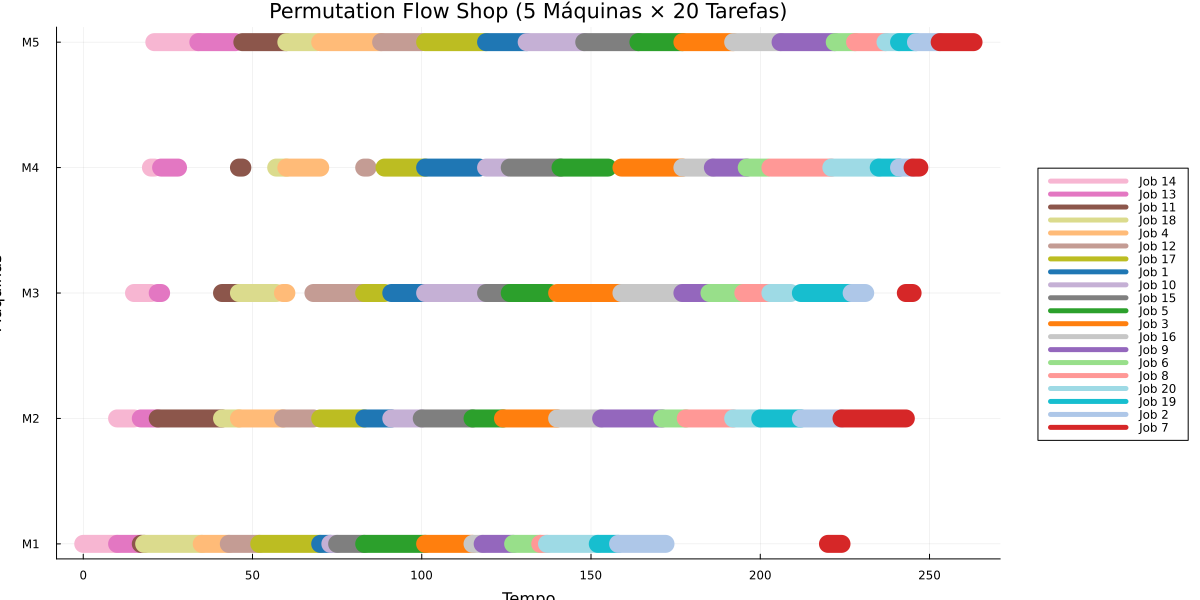

In [30]:
# ==========================================================
# 5. RESULTADOS
# ==========================================================

if has_values(model)

    println("---------------------------------------")
    println("Makespan = ", objective_value(model))
    println("---------------------------------------")

    # Recupera a sequência das tarefas

    sequencia = Int[]

    for k in 1:num_jobs
        for j in 1:num_jobs
            if value(x[j,k]) > 0.5
                push!(sequencia,j)
            end
        end
    end

    println("\nSequência encontrada:")

    println(sequencia)

    # ======================================================
    # 6. GRÁFICO DE GANTT
    # ======================================================

    cores = palette(:tab20)

    gantt = plot(
        title="Permutation Flow Shop (5 Máquinas × 20 Tarefas)",
        xlabel="Tempo",
        ylabel="Máquinas",
        yticks=(1:num_machines,
                ["M$i" for i in 1:num_machines]),
        legend=:outerright,
        size=(1200,600)
    )

    for m in 1:num_machines

        for k in 1:num_jobs

            job = sequencia[k]

            inicio = value(s[m,k])

            fim = inicio + p[job,m]

            plot!(
                gantt,
                [inicio,fim],
                [m,m],
                linewidth=18,
                color=cores[job],
                label=(m==1 ? "Job $job" : "")
            )

        end

    end

    savefig(gantt,"gantt_problem_5m_20j.png")

    println("\nGráfico salvo como:")
    println("gantt_problem_5m_20j.png")

    display(gantt)

else

    println("Nenhuma solução viável encontrada.")

end

Intância problem_8m_10
===============

In [31]:
using CSV
using DataFrames
using JuMP
using HiGHS
using Plots

In [32]:
# ==========================================================
# 1. LEITURA DA INSTÂNCIA
# ==========================================================

println("Carregando instância...")

arquivo = "problem_8m_10j.csv"

df = CSV.read(arquivo, DataFrame)


Carregando instância...


Row,Column1,M1,M2,M3,M4,M5,M6,M7,M8
,String3,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64
1,J1,3,14,7,8,11,1,5,14
2,J2,18,4,12,4,10,2,19,15
3,J3,11,2,11,15,8,7,17,14
4,J4,14,12,2,9,3,16,1,6
5,J5,9,7,1,11,17,19,10,19
6,J6,19,12,18,11,12,13,10,18
7,J7,7,2,15,12,18,16,11,4
8,J8,1,19,7,8,7,19,19,8
9,J9,6,4,11,9,17,17,5,17


In [33]:
# Remove a primeira coluna caso contenha o identificador das tarefas
if eltype(df[:,1]) <: AbstractString
    p = Matrix(df[:,2:end])
else
    p = Matrix(df)
end

num_jobs = size(p,1)
num_machines = size(p,2)

println("Instância carregada com sucesso!")
println("Número de tarefas : $num_jobs")
println("Número de máquinas: $num_machines")


Instância carregada com sucesso!
Número de tarefas : 10
Número de máquinas: 8


In [34]:
# ==========================================================
# 2. MODELO MATEMÁTICO
# ==========================================================

model = Model(HiGHS.Optimizer)


A JuMP Model
├ solver: HiGHS
├ objective_sense: FEASIBILITY_SENSE
├ num_variables: 0
├ num_constraints: 0
└ Names registered in the model: none

In [35]:
# Limite de tempo (30 segundos)
set_attribute(model, "time_limit", 30.0)

# Variáveis de decisão

@variable(model, x[1:num_jobs,1:num_jobs], Bin)

@variable(model, s[1:num_machines,1:num_jobs] >= 0)

@variable(model, Cmax >= 0)

# Função objetivo

@objective(model, Min, Cmax)


Cmax

In [36]:
# ==========================================================
# 3. RESTRIÇÕES
# ==========================================================

# Cada tarefa ocupa exatamente uma posição

@constraint(model,
    [j=1:num_jobs],
    sum(x[j,k] for k in 1:num_jobs) == 1
)

10-element Vector{ConstraintRef{Model, MathOptInterface.ConstraintIndex{MathOptInterface.ScalarAffineFunction{Float64}, MathOptInterface.EqualTo{Float64}}, ScalarShape}}:
 x[1,1] + x[1,2] + x[1,3] + x[1,4] + x[1,5] + x[1,6] + x[1,7] + x[1,8] + x[1,9] + x[1,10] == 1
 x[2,1] + x[2,2] + x[2,3] + x[2,4] + x[2,5] + x[2,6] + x[2,7] + x[2,8] + x[2,9] + x[2,10] == 1
 x[3,1] + x[3,2] + x[3,3] + x[3,4] + x[3,5] + x[3,6] + x[3,7] + x[3,8] + x[3,9] + x[3,10] == 1
 x[4,1] + x[4,2] + x[4,3] + x[4,4] + x[4,5] + x[4,6] + x[4,7] + x[4,8] + x[4,9] + x[4,10] == 1
 x[5,1] + x[5,2] + x[5,3] + x[5,4] + x[5,5] + x[5,6] + x[5,7] + x[5,8] + x[5,9] + x[5,10] == 1
 x[6,1] + x[6,2] + x[6,3] + x[6,4] + x[6,5] + x[6,6] + x[6,7] + x[6,8] + x[6,9] + x[6,10] == 1
 x[7,1] + x[7,2] + x[7,3] + x[7,4] + x[7,5] + x[7,6] + x[7,7] + x[7,8] + x[7,9] + x[7,10] == 1
 x[8,1] + x[8,2] + x[8,3] + x[8,4] + x[8,5] + x[8,6] + x[8,7] + x[8,8] + x[8,9] + x[8,10] == 1
 x[9,1] + x[9,2] + x[9,3] + x[9,4] + x[9,5] + x[9,6] + x[9,7] + x[9,8

In [37]:
# Cada posição recebe exatamente uma tarefa

@constraint(model,
    [k=1:num_jobs],
    sum(x[j,k] for j in 1:num_jobs) == 1
)


10-element Vector{ConstraintRef{Model, MathOptInterface.ConstraintIndex{MathOptInterface.ScalarAffineFunction{Float64}, MathOptInterface.EqualTo{Float64}}, ScalarShape}}:
 x[1,1] + x[2,1] + x[3,1] + x[4,1] + x[5,1] + x[6,1] + x[7,1] + x[8,1] + x[9,1] + x[10,1] == 1
 x[1,2] + x[2,2] + x[3,2] + x[4,2] + x[5,2] + x[6,2] + x[7,2] + x[8,2] + x[9,2] + x[10,2] == 1
 x[1,3] + x[2,3] + x[3,3] + x[4,3] + x[5,3] + x[6,3] + x[7,3] + x[8,3] + x[9,3] + x[10,3] == 1
 x[1,4] + x[2,4] + x[3,4] + x[4,4] + x[5,4] + x[6,4] + x[7,4] + x[8,4] + x[9,4] + x[10,4] == 1
 x[1,5] + x[2,5] + x[3,5] + x[4,5] + x[5,5] + x[6,5] + x[7,5] + x[8,5] + x[9,5] + x[10,5] == 1
 x[1,6] + x[2,6] + x[3,6] + x[4,6] + x[5,6] + x[6,6] + x[7,6] + x[8,6] + x[9,6] + x[10,6] == 1
 x[1,7] + x[2,7] + x[3,7] + x[4,7] + x[5,7] + x[6,7] + x[7,7] + x[8,7] + x[9,7] + x[10,7] == 1
 x[1,8] + x[2,8] + x[3,8] + x[4,8] + x[5,8] + x[6,8] + x[7,8] + x[8,8] + x[9,8] + x[10,8] == 1
 x[1,9] + x[2,9] + x[3,9] + x[4,9] + x[5,9] + x[6,9] + x[7,9] + x[8,9

In [38]:
# Precedência na mesma máquina

@constraint(model,
    [m=1:num_machines, k=1:num_jobs-1],
    s[m,k+1] >=
        s[m,k] +
        sum(p[j,m] * x[j,k] for j in 1:num_jobs)
)


8×9 Matrix{ConstraintRef{Model, MathOptInterface.ConstraintIndex{MathOptInterface.ScalarAffineFunction{Float64}, MathOptInterface.GreaterThan{Float64}}, ScalarShape}}:
 -3 x[1,1] - 18 x[2,1] - 11 x[3,1] - 14 x[4,1] - 9 x[5,1] - 19 x[6,1] - 7 x[7,1] - x[8,1] - 6 x[9,1] - 6 x[10,1] - s[1,1] + s[1,2] >= 0      …  -3 x[1,9] - 18 x[2,9] - 11 x[3,9] - 14 x[4,9] - 9 x[5,9] - 19 x[6,9] - 7 x[7,9] - x[8,9] - 6 x[9,9] - 6 x[10,9] - s[1,9] + s[1,10] >= 0
 -14 x[1,1] - 4 x[2,1] - 2 x[3,1] - 12 x[4,1] - 7 x[5,1] - 12 x[6,1] - 2 x[7,1] - 19 x[8,1] - 4 x[9,1] - 13 x[10,1] - s[2,1] + s[2,2] >= 0      -14 x[1,9] - 4 x[2,9] - 2 x[3,9] - 12 x[4,9] - 7 x[5,9] - 12 x[6,9] - 2 x[7,9] - 19 x[8,9] - 4 x[9,9] - 13 x[10,9] - s[2,9] + s[2,10] >= 0
 -7 x[1,1] - 12 x[2,1] - 11 x[3,1] - 2 x[4,1] - x[5,1] - 18 x[6,1] - 15 x[7,1] - 7 x[8,1] - 11 x[9,1] - 4 x[10,1] - s[3,1] + s[3,2] >= 0        -7 x[1,9] - 12 x[2,9] - 11 x[3,9] - 2 x[4,9] - x[5,9] - 18 x[6,9] - 15 x[7,9] - 7 x[8,9] - 11 x[9,9] - 4 x[10,9] - s[3,9] + s

In [39]:
# Precedência entre máquinas

@constraint(model,
    [m=1:num_machines-1, k=1:num_jobs],
    s[m+1,k] >=
        s[m,k] +
        sum(p[j,m] * x[j,k] for j in 1:num_jobs)
)


7×10 Matrix{ConstraintRef{Model, MathOptInterface.ConstraintIndex{MathOptInterface.ScalarAffineFunction{Float64}, MathOptInterface.GreaterThan{Float64}}, ScalarShape}}:
 -3 x[1,1] - 18 x[2,1] - 11 x[3,1] - 14 x[4,1] - 9 x[5,1] - 19 x[6,1] - 7 x[7,1] - x[8,1] - 6 x[9,1] - 6 x[10,1] - s[1,1] + s[2,1] >= 0      …  -3 x[1,10] - 18 x[2,10] - 11 x[3,10] - 14 x[4,10] - 9 x[5,10] - 19 x[6,10] - 7 x[7,10] - x[8,10] - 6 x[9,10] - 6 x[10,10] - s[1,10] + s[2,10] >= 0
 -14 x[1,1] - 4 x[2,1] - 2 x[3,1] - 12 x[4,1] - 7 x[5,1] - 12 x[6,1] - 2 x[7,1] - 19 x[8,1] - 4 x[9,1] - 13 x[10,1] - s[2,1] + s[3,1] >= 0      -14 x[1,10] - 4 x[2,10] - 2 x[3,10] - 12 x[4,10] - 7 x[5,10] - 12 x[6,10] - 2 x[7,10] - 19 x[8,10] - 4 x[9,10] - 13 x[10,10] - s[2,10] + s[3,10] >= 0
 -7 x[1,1] - 12 x[2,1] - 11 x[3,1] - 2 x[4,1] - x[5,1] - 18 x[6,1] - 15 x[7,1] - 7 x[8,1] - 11 x[9,1] - 4 x[10,1] - s[3,1] + s[4,1] >= 0        -7 x[1,10] - 12 x[2,10] - 11 x[3,10] - 2 x[4,10] - x[5,10] - 18 x[6,10] - 15 x[7,10] - 7 x[8,10] - 11 

In [40]:
# Makespan

@constraint(model,
    Cmax >=
        s[num_machines,num_jobs] +
        sum(p[j,num_machines] * x[j,num_jobs] for j in 1:num_jobs)
)


-14 x[1,10] - 15 x[2,10] - 14 x[3,10] - 6 x[4,10] - 19 x[5,10] - 18 x[6,10] - 4 x[7,10] - 8 x[8,10] - 17 x[9,10] - 3 x[10,10] - s[8,10] + Cmax >= 0

In [41]:
# ==========================================================
# 4. OTIMIZAÇÃO
# ==========================================================

println("\nIniciando otimização...")

optimize!(model)

status = termination_status(model)

println("\nStatus do Solver: ", status)



Iniciando otimização...
Running HiGHS 1.14.0 (git hash: 7df0786de3): Copyright (c) 2026 under Apache 2.0 license terms
Using BLAS: blastrampoline-5 
MIP has 163 rows; 181 cols; 1916 nonzeros; 100 integer variables (100 binary)
Coefficient ranges:
  Matrix  [1e+00, 2e+01]
  Cost    [1e+00, 1e+00]
  Bound   [1e+00, 1e+00]
  RHS     [1e+00, 1e+00]
Presolving model
162 rows, 179 cols, 1902 nonzeros 0s
137 rows, 154 cols, 1533 nonzeros 0s
Presolve reductions: rows 137(-26); columns 154(-27); nonzeros 1533(-383) 

Solving MIP model with:
   137 rows
   154 cols (100 binary, 0 integer, 0 implied int., 54 continuous, 0 domain fixed)
   1533 nonzeros

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic;
     I => Shifting; J => Feasibility jump; L => Sub-MIP; P => Empty MIP; R => Randomized rounding;
     S => Solve LP; T => Evaluate node; U => Unbounded; X => User solution; Y => HiGHS solution;
     Z => ZI Round; l => Trivial lower; p => Trivial point; u => Triv

Makespan = 186.99999999999997

Sequência encontrada:
[9, 1, 3, 8, 5, 10, 6, 2, 4, 7]

Gráfico salvo como:
gantt_problem_8m_10j.png


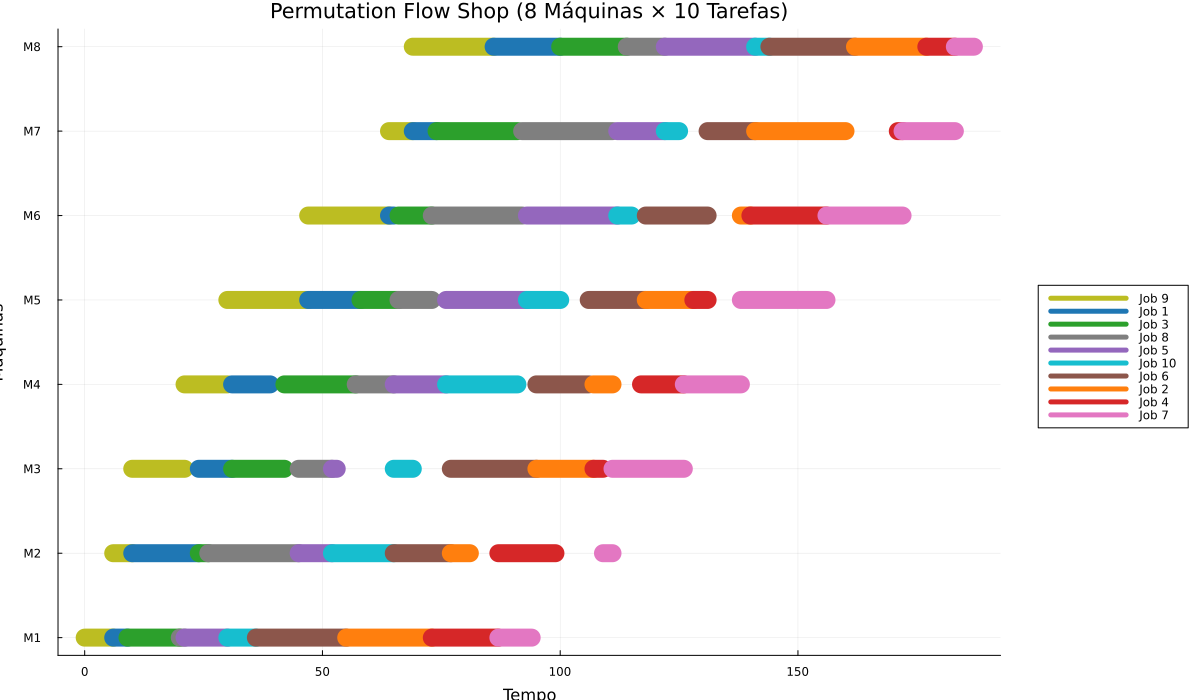

In [42]:
# ==========================================================
# 5. RESULTADOS
# ==========================================================

if has_values(model)

    println("========================================")
    println("Makespan = ", objective_value(model))
    println("========================================")

    sequencia = Int[]

    for k in 1:num_jobs
        for j in 1:num_jobs
            if value(x[j,k]) > 0.5
                push!(sequencia,j)
            end
        end
    end

    println("\nSequência encontrada:")
    println(sequencia)

    # ======================================================
    # 6. GRÁFICO DE GANTT
    # ======================================================

    cores = palette(:tab10)

    gantt = plot(
        title = "Permutation Flow Shop (8 Máquinas × 10 Tarefas)",
        xlabel = "Tempo",
        ylabel = "Máquinas",
        yticks = (1:num_machines,
                  ["M$i" for i in 1:num_machines]),
        legend = :outerright,
        size = (1200,700)
    )

    for m in 1:num_machines

        for k in 1:num_jobs

            job = sequencia[k]

            inicio = value(s[m,k])

            fim = inicio + p[job,m]

            plot!(
                gantt,
                [inicio, fim],
                [m, m],
                linewidth = 18,
                color = cores[job],
                label = (m == 1 ? "Job $job" : "")
            )

        end

    end

    savefig(gantt, "gantt_problem_8m_10j.png")

    println("\nGráfico salvo como:")
    println("gantt_problem_8m_10j.png")

    display(gantt)

else

    println("Nenhuma solução viável encontrada.")

end